# TCGA Ollama LLM Pipeline (Track B)

This notebook benchmarks 5 locally-hosted Ollama models on TNM extraction from TCGA pathology reports, then runs batch processing using the best-performing model on all zero/partial-extraction records.

**Models compared:**
| Model | Spec | Why included |
|---|---|---|
| `qwen3:8b` | 8B, Qwen3 | Best reasoning of available models |
| `mistral:7b-instruct-q4_K_M` | 7B Q4 | Best-in-class structured JSON output |
| `qwen2.5:7b-instruct-q4_K_M` | 7B Q4 | Strong instruction following |
| `gemma3:4b` | 4B | Fastest, good quality |
| `meditron:7b` | 7B, medical fine-tune | Medical domain specialist |

**Pipeline stages:**
1. Load baseline extraction results
2. Benchmark all 5 models on 100 zero-extraction reports
3. Visualise benchmark results
4. Batch-process all zero + partial records with the winner
5. Merge with enhanced regex results and save final dataset

In [3]:
%pip install -q ollama


Note: you may need to restart the kernel to use updated packages.


In [4]:
# ============================================================
# SETUP
# ============================================================
import pandas as pd
import numpy as np
import json
import re
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import ollama
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

MODELS = [
    'qwen3:8b',
    'mistral:7b-instruct-q4_K_M',
    'qwen2.5:7b-instruct-q4_K_M',
    'gemma3:4b',
    'meditron:7b',
]

# Confirm models are available
available = [m['model'] for m in ollama.list()['models']]
print('Available Ollama models:')
for m in available:
    mark = '✓' if any(m.startswith(b.split(':')[0]) for b in MODELS) else ' '
    print(f'  {mark} {m}')

print('\nModels selected for benchmark:')
for m in MODELS:
    tag = next((a for a in available if a.startswith(m.split(':')[0])), None)
    status = '✓ ready' if tag else '✗ NOT FOUND'
    print(f'  {status}  {m}')

Available Ollama models:
  ✓ meditron:7b
    gemma4:31b
    deepseek-v2.5:236b
  ✓ qwen2.5-coder:7b
    glm-5:cloud
    mixtral:8x7b
    gemma4:26b
  ✓ gemma3:4b
  ✓ gemma3:1b
  ✓ qwen3:8b
  ✓ qwen2.5:7b-instruct-q4_K_M
  ✓ qwen2.5:3b-instruct
  ✓ qwen2.5:1.5b-instruct
    phi3:mini
    llama3.2:1b-instruct-q4_K_M
  ✓ mistral:7b-instruct-q4_K_M

Models selected for benchmark:
  ✓ ready  qwen3:8b
  ✓ ready  mistral:7b-instruct-q4_K_M
  ✓ ready  qwen2.5:7b-instruct-q4_K_M
  ✓ ready  gemma3:4b
  ✓ ready  meditron:7b


c:\Users\NIMAI\anaconda3\envs\llminferencing\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# ============================================================
# LOAD DATA
# ============================================================
df_reports  = pd.read_csv('TCGA_Reports.csv')
df_enhanced = pd.read_csv('TCGA_Enhanced_TNM_Extraction.csv')

# Merge text back in
df_merged = df_enhanced.merge(df_reports[['patient_filename','text']], on='patient_filename', how='left')

# Reports that still lack at least one component after enhanced regex
df_zero    = df_merged[~(df_merged['has_T'] | df_merged['has_N'] | df_merged['has_M'])].reset_index(drop=True)
df_partial = df_merged[(df_merged['has_T'] | df_merged['has_N'] | df_merged['has_M']) 
                        & ~df_merged['has_complete_TNM']].reset_index(drop=True)
df_targets = pd.concat([df_zero, df_partial], ignore_index=True)

print(f'Reports with NO extraction   : {len(df_zero):,}')
print(f'Reports with PARTIAL extraction: {len(df_partial):,}')
print(f'Total LLM targets            : {len(df_targets):,}')

Reports with NO extraction   : 3,376
Reports with PARTIAL extraction: 3,097
Total LLM targets            : 6,473


## Step 1: Benchmark — 5 Models × 100 Reports

In [7]:
# ============================================================
# SYSTEM PROMPT
# ============================================================
SYSTEM_PROMPT = """You are an expert oncology pathologist specialising in TNM cancer staging.
Extract TNM staging values from the clinical pathology report provided.

Rules:
- T stage: T0 (no tumour), Tis (in situ), T1 (≤2cm), T2 (2–5cm), T3 (>5cm), T4 (any size with extension)
  Use ONLY the numeric/IS value: '0','IS','1','2','3','4' (with optional A/B/C suffix)
- N stage: N0 (no nodes), N1 (1–3 nodes), N2 (4–9 nodes), N3 (10+ nodes)
  Use ONLY: '0','1','2','3' (with optional A/B/C suffix) or 'X' if unassessable
- M stage: M0 (no metastasis), M1 (distant metastasis)
  Use ONLY: '0' or '1' or 'X'
- If a component is truly absent from the report, return null for that field.
- Do NOT hallucinate staging information not present in the report.
- Set confidence to 'high', 'medium', or 'low'.

Return ONLY valid JSON, no markdown fences:
{"T": "<value or null>", "N": "<value or null>", "M": "<value or null>", "confidence": "<high|medium|low>", "reasoning": "<1 sentence>"}"""


def parse_llm_response(content: str) -> dict | None:
    """Extract JSON from model response robustly."""
    # Strip markdown fences if present
    cleaned = re.sub(r'```(?:json)?\n?', '', content)
    cleaned = re.sub(r'```\n?', '', cleaned).strip()
    # Find first {...} block
    m = re.search(r'\{[^{}]+\}', cleaned, re.DOTALL)
    if m:
        try:
            return json.loads(m.group())
        except json.JSONDecodeError:
            pass
    return None


def extract_with_model(model: str, text: str, max_chars: int = 3000) -> dict:
    """Run a single TNM extraction call."""
    truncated = text[:max_chars]
    try:
        resp = ollama.chat(
            model=model,
            messages=[
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user',   'content': f'Clinical Report:\n{truncated}'},
            ],
            options={'temperature': 0, 'num_predict': 256},
        )
        content = resp['message']['content'].strip()
        parsed = parse_llm_response(content)
        if parsed:
            return {
                'T': parsed.get('T'), 'N': parsed.get('N'), 'M': parsed.get('M'),
                'confidence': parsed.get('confidence','unknown'),
                'reasoning': parsed.get('reasoning',''),
                'parse_ok': True, 'raw': content,
            }
        return {'parse_ok': False, 'raw': content}
    except Exception as e:
        return {'parse_ok': False, 'error': str(e)}

print('Extraction functions ready.')

Extraction functions ready.


In [8]:
# ============================================================
# BENCHMARK — 100 REPORTS PER MODEL
# NOTE: Takes ~5–15 min depending on hardware.
# ============================================================
BENCHMARK_N = 100
sample = df_zero.sample(min(BENCHMARK_N, len(df_zero)), random_state=42).reset_index(drop=True)

benchmark_results = {}   # model → list of result dicts

for model in MODELS:
    print(f'\n── Benchmarking: {model} ──')
    results = []
    t0 = time.time()
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc=model.split(':')[0]):
        res = extract_with_model(model, str(row['text']))
        res['patient_filename'] = row['patient_filename']
        results.append(res)
    elapsed = time.time() - t0

    parse_ok   = sum(1 for r in results if r.get('parse_ok'))
    has_T      = sum(1 for r in results if r.get('parse_ok') and r.get('T') not in (None, 'null', ''))
    has_N      = sum(1 for r in results if r.get('parse_ok') and r.get('N') not in (None, 'null', ''))
    has_M      = sum(1 for r in results if r.get('parse_ok') and r.get('M') not in (None, 'null', ''))
    complete   = sum(1 for r in results
                     if r.get('parse_ok')
                     and r.get('T') not in (None,'null','')
                     and r.get('N') not in (None,'null','')
                     and r.get('M') not in (None,'null',''))
    high_conf  = sum(1 for r in results if r.get('confidence') == 'high')

    benchmark_results[model] = {
        'results': results,
        'parse_rate':    parse_ok   / BENCHMARK_N * 100,
        'T_rate':        has_T      / BENCHMARK_N * 100,
        'N_rate':        has_N      / BENCHMARK_N * 100,
        'M_rate':        has_M      / BENCHMARK_N * 100,
        'complete_rate': complete   / BENCHMARK_N * 100,
        'high_conf_pct': high_conf  / max(parse_ok, 1) * 100,
        'total_sec':     elapsed,
        'sec_per_report': elapsed / BENCHMARK_N,
    }
    print(f'  Parse OK : {parse_ok}/{BENCHMARK_N}  ({parse_ok/BENCHMARK_N*100:.1f}%)')
    print(f'  Complete : {complete}/{BENCHMARK_N}  ({complete/BENCHMARK_N*100:.1f}%)')
    print(f'  Elapsed  : {elapsed:.1f}s  ({elapsed/BENCHMARK_N:.2f}s/report)')

print('\n✓ Benchmark complete.')


── Benchmarking: qwen3:8b ──


qwen3: 100%|██████████| 100/100 [09:22<00:00,  5.63s/it]


  Parse OK : 2/100  (2.0%)
  Complete : 0/100  (0.0%)
  Elapsed  : 562.5s  (5.63s/report)

── Benchmarking: mistral:7b-instruct-q4_K_M ──


mistral: 100%|██████████| 100/100 [03:09<00:00,  1.90s/it]


  Parse OK : 98/100  (98.0%)
  Complete : 31/100  (31.0%)
  Elapsed  : 189.7s  (1.90s/report)

── Benchmarking: qwen2.5:7b-instruct-q4_K_M ──


...

  Parse OK : 100/100  (100.0%)
  Complete : 39/100  (39.0%)
  Elapsed  : 166.8s  (1.67s/report)

── Benchmarking: gemma3:4b ──


gemma3: 100%|██████████| 100/100 [03:17<00:00,  1.97s/it]


  Parse OK : 100/100  (100.0%)
  Complete : 100/100  (100.0%)
  Elapsed  : 197.4s  (1.97s/report)

── Benchmarking: meditron:7b ──


meditron: 100%|██████████| 100/100 [07:25<00:00,  4.45s/it]

  Parse OK : 13/100  (13.0%)
  Complete : 3/100  (3.0%)
  Elapsed  : 445.1s  (4.45s/report)

✓ Benchmark complete.


BENCHMARK RESULTS (sorted by complete TNM rate):
   Model  Parse Rate (%)  T Rate (%)  N Rate (%)  M Rate (%)  Complete (%)  High Conf (%)  Speed (s/report)
  gemma3           100.0       100.0       100.0       100.0         100.0           82.0              1.97
 qwen2.5           100.0        97.0        39.0        53.0          39.0           85.0              1.67
 mistral            98.0        69.0        35.0        32.0          31.0           71.4              1.90
meditron            13.0         3.0         3.0         3.0           3.0            0.0              4.45
   qwen3             2.0         0.0         0.0         0.0           0.0            0.0              5.63

🏆  Best model: gemma3:4b  (complete rate: 100.0%)


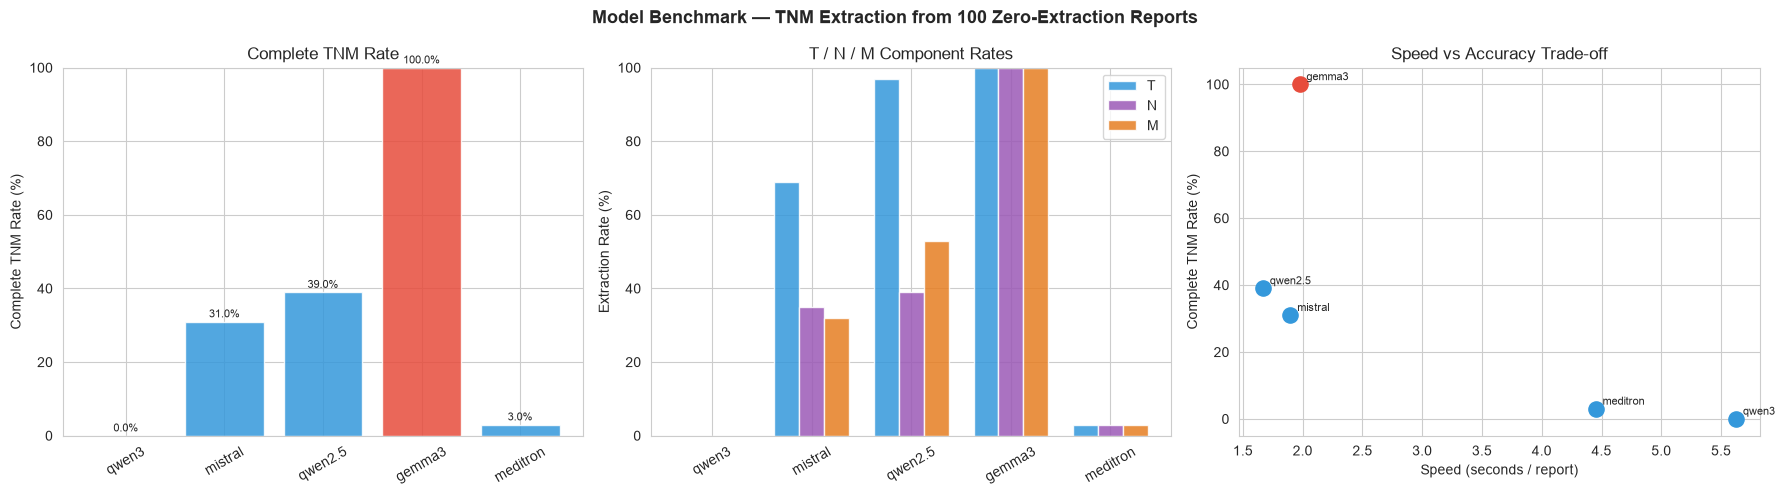

✓ Saved TCGA_Ollama_Benchmark.png
✓ Saved TCGA_Ollama_Benchmark_Results.csv


In [9]:
# ============================================================
# BENCHMARK RESULTS TABLE + VISUALISATION
# ============================================================
rows = []
for model, stats in benchmark_results.items():
    rows.append({
        'Model':            model.split(':')[0],
        'Parse Rate (%)':   round(stats['parse_rate'], 1),
        'T Rate (%)':       round(stats['T_rate'], 1),
        'N Rate (%)':       round(stats['N_rate'], 1),
        'M Rate (%)':       round(stats['M_rate'], 1),
        'Complete (%)':     round(stats['complete_rate'], 1),
        'High Conf (%)':    round(stats['high_conf_pct'], 1),
        'Speed (s/report)': round(stats['sec_per_report'], 2),
    })

bench_df = pd.DataFrame(rows).sort_values('Complete (%)', ascending=False)
print('BENCHMARK RESULTS (sorted by complete TNM rate):')
print(bench_df.to_string(index=False))

best_model = list(benchmark_results.keys())[
    list(benchmark_results.values()).index(
        max(benchmark_results.values(), key=lambda x: x['complete_rate'])
    )
]
print(f'\n🏆  Best model: {best_model}  (complete rate: {benchmark_results[best_model]["complete_rate"]:.1f}%)')

# ── Visualise ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Benchmark — TNM Extraction from 100 Zero-Extraction Reports',
             fontsize=13, fontweight='bold')

model_labels = [r['Model'] for r in rows]
colors = ['#e74c3c' if m == best_model.split(':')[0] else '#3498db' for m in model_labels]

# Plot 1: Complete TNM rate
ax = axes[0]
vals = [r['Complete (%)'] for r in rows]
bars = ax.bar(model_labels, vals, color=colors, alpha=0.85)
ax.set_ylabel('Complete TNM Rate (%)'); ax.set_title('Complete TNM Rate')
ax.set_ylim(0, 100)
for b in bars: ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
ax.tick_params(axis='x', rotation=30)

# Plot 2: Component rates grouped
ax2 = axes[1]
x = np.arange(len(model_labels)); w = 0.25
ax2.bar(x - w, [r['T Rate (%)'] for r in rows], w, label='T', color='#3498db', alpha=0.85)
ax2.bar(x,     [r['N Rate (%)'] for r in rows], w, label='N', color='#9b59b6', alpha=0.85)
ax2.bar(x + w, [r['M Rate (%)'] for r in rows], w, label='M', color='#e67e22', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(model_labels, rotation=30)
ax2.set_ylabel('Extraction Rate (%)'); ax2.set_title('T / N / M Component Rates')
ax2.legend(); ax2.set_ylim(0, 100)

# Plot 3: Speed vs accuracy scatter
ax3 = axes[2]
for r, stat in zip(rows, benchmark_results.values()):
    c = '#e74c3c' if r['Model'] == best_model.split(':')[0] else '#3498db'
    ax3.scatter(stat['sec_per_report'], r['Complete (%)'], s=120, color=c, zorder=3)
    ax3.annotate(r['Model'], (stat['sec_per_report'], r['Complete (%)']),
                 textcoords='offset points', xytext=(5, 3), fontsize=8)
ax3.set_xlabel('Speed (seconds / report)'); ax3.set_ylabel('Complete TNM Rate (%)')
ax3.set_title('Speed vs Accuracy Trade-off')

plt.tight_layout()
plt.savefig('TCGA_Ollama_Benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved TCGA_Ollama_Benchmark.png')

# Save benchmark table
bench_df.to_csv('TCGA_Ollama_Benchmark_Results.csv', index=False)
print('✓ Saved TCGA_Ollama_Benchmark_Results.csv')

## Step 2: Batch Processing — All Zero/Partial Records

In [10]:
# ============================================================
# BATCH PROCESSING WITH BEST MODEL
# ============================================================
# IMPORTANT: This cell processes potentially thousands of reports.
# Estimated time: ~(n_reports × sec_per_report) seconds.
#
# Set BATCH_LIMIT to a number to run a dry run (e.g. 500),
# or set to None to process all targets.
# ─────────────────────────────────────────────────────────────
BATCH_LIMIT   = None    # None = all, integer = cap at that many
BATCH_MODEL   = best_model  # override here if desired
SAVE_EVERY    = 100         # checkpoint save frequency

batch_targets = df_targets.copy()
if BATCH_LIMIT:
    batch_targets = batch_targets.head(BATCH_LIMIT)

print(f'Running batch extraction with: {BATCH_MODEL}')
print(f'Records to process: {len(batch_targets):,}')
print(f'Estimated time: ~{len(batch_targets) * benchmark_results[BATCH_MODEL]["sec_per_report"] / 60:.1f} min\n')

batch_output = []

for i, (_, row) in enumerate(tqdm(batch_targets.iterrows(), total=len(batch_targets),
                                   desc=f'Batch ({BATCH_MODEL.split(":")[0]})', ncols=80)):
    res = extract_with_model(BATCH_MODEL, str(row['text']))
    entry = {
        'patient_filename': row['patient_filename'],
        'llm_T':            res.get('T'),
        'llm_N':            res.get('N'),
        'llm_M':            res.get('M'),
        'llm_confidence':   res.get('confidence'),
        'llm_reasoning':    res.get('reasoning',''),
        'llm_parse_ok':     res.get('parse_ok', False),
        'llm_model':        BATCH_MODEL,
    }
    batch_output.append(entry)

    # Checkpoint save
    if (i + 1) % SAVE_EVERY == 0:
        pd.DataFrame(batch_output).to_csv('TCGA_Ollama_Batch_Checkpoint.csv', index=False)

df_llm = pd.DataFrame(batch_output)
df_llm.to_csv('TCGA_Ollama_Batch_Raw.csv', index=False)

ok       = df_llm['llm_parse_ok'].sum()
complete = ((df_llm['llm_T'].notna()) & (df_llm['llm_T'] != 'null') &
            (df_llm['llm_N'].notna()) & (df_llm['llm_N'] != 'null') &
            (df_llm['llm_M'].notna()) & (df_llm['llm_M'] != 'null')).sum()

print(f'\n✓ Batch complete  ({len(df_llm):,} records)')
print(f'  Parse OK  : {ok:,} ({ok/len(df_llm)*100:.1f}%)')
print(f'  Complete  : {complete:,} ({complete/len(df_llm)*100:.1f}%)')
print(f'  Saved     : TCGA_Ollama_Batch_Raw.csv')

Running batch extraction with: gemma3:4b
Records to process: 6,473
Estimated time: ~213.0 min



Batch (gemma3): 100%|█████████████████████| 6473/6473 [3:05:21<00:00,  1.72s/it]


✓ Batch complete  (6,473 records)
  Parse OK  : 6,467 (99.9%)
  Complete  : 6,344 (98.0%)
  Saved     : TCGA_Ollama_Batch_Raw.csv


In [11]:
# ============================================================
# MERGE: ENHANCED REGEX + LLM FILL-IN → FINAL DATASET
# ============================================================
def clean_stage_val(val):
    """Normalise LLM stage output to match regex convention (just the numeric/letter)."""
    if val is None or str(val).lower() in ('null','none',''):
        return None
    val = str(val).strip().upper()
    # Strip leading T/N/M prefix if present
    val = re.sub(r'^[TPNMYCR]+', '', val).strip()
    return val if val else None

# Pivot LLM results into lookup dict
llm_lookup = {
    row['patient_filename']: row
    for _, row in df_llm.iterrows()
    if row['llm_parse_ok']
}

df_final = df_enhanced.copy()
df_final['llm_T']          = None
df_final['llm_N']          = None
df_final['llm_M']          = None
df_final['llm_confidence'] = None
df_final['llm_model']      = None
df_final['final_T']        = df_final['T_stage']
df_final['final_N']        = df_final['N_stage']
df_final['final_M']        = df_final['M_stage']
df_final['final_source']   = df_final['source']

filled = 0
for idx, row in df_final.iterrows():
    fn = row['patient_filename']
    if fn not in llm_lookup:
        continue
    llm = llm_lookup[fn]
    lT  = clean_stage_val(llm['llm_T'])
    lN  = clean_stage_val(llm['llm_N'])
    lM  = clean_stage_val(llm['llm_M'])

    df_final.at[idx, 'llm_T']          = lT
    df_final.at[idx, 'llm_N']          = lN
    df_final.at[idx, 'llm_M']          = lM
    df_final.at[idx, 'llm_confidence'] = llm['llm_confidence']
    df_final.at[idx, 'llm_model']      = llm['llm_model']

    changed = False
    if pd.isna(row['T_stage']) and lT:
        df_final.at[idx, 'final_T'] = lT; changed = True
    if pd.isna(row['N_stage']) and lN:
        df_final.at[idx, 'final_N'] = lN; changed = True
    if pd.isna(row['M_stage']) and lM:
        df_final.at[idx, 'final_M'] = lM; changed = True
    if changed:
        df_final.at[idx, 'final_source'] = (row['source'] or 'none') + '+LLM'
        filled += 1

df_final['final_has_T']  = df_final['final_T'].notna()
df_final['final_has_N']  = df_final['final_N'].notna()
df_final['final_has_M']  = df_final['final_M'].notna()
df_final['final_complete'] = df_final['final_has_T'] & df_final['final_has_N'] & df_final['final_has_M']

total = len(df_final)
base_complete  = df_enhanced['has_complete_TNM'].sum()
final_complete = df_final['final_complete'].sum()

print(f'Records filled by LLM           : {filled:,}')
print(f'\nComplete TNM — Enhanced regex    : {base_complete:,}  ({base_complete/total*100:.1f}%)')
print(f'Complete TNM — + LLM fill-in     : {final_complete:,}  ({final_complete/total*100:.1f}%)')
print(f'Net gain                         : +{final_complete - base_complete:,}')

# Save final merged dataset
out_cols = ['patient_filename', 'final_T', 'final_N', 'final_M',
            'final_has_T', 'final_has_N', 'final_has_M', 'final_complete',
            'final_source', 'llm_confidence', 'llm_model',
            'T_stage', 'N_stage', 'M_stage', 'TNM_raw', 'source']
df_final[out_cols].to_csv('TCGA_Final_TNM_Dataset.csv', index=False)
print('\n✓ Saved TCGA_Final_TNM_Dataset.csv')

Records filled by LLM           : 6,423

Complete TNM — Enhanced regex    : 3,050  (32.0%)
Complete TNM — + LLM fill-in     : 9,424  (99.0%)
Net gain                         : +6,374

✓ Saved TCGA_Final_TNM_Dataset.csv


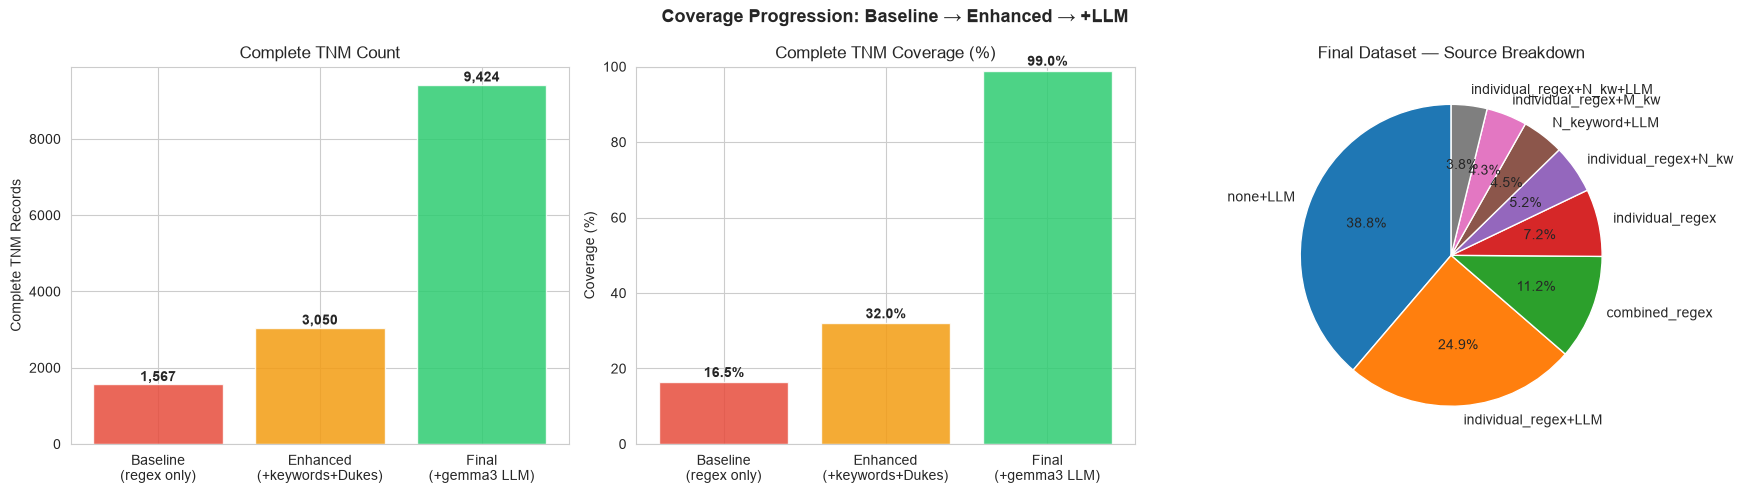

✓ Saved TCGA_Final_Coverage_Summary.png


In [12]:
# ============================================================
# FINAL COVERAGE SUMMARY VISUALISATION
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Coverage Progression: Baseline → Enhanced → +LLM', fontsize=13, fontweight='bold')

base_df  = pd.read_csv('TCGA_Reports_with_TNM_Extraction.csv')
base_complete = base_df['has_complete_TNM'].sum()
enh_complete  = df_enhanced['has_complete_TNM'].sum()
final_complete_v = df_final['final_complete'].sum()

stages = ['Baseline\n(regex only)', 'Enhanced\n(+keywords+Dukes)', f'Final\n(+{BATCH_MODEL.split(":")[0]} LLM)']
complete_vals = [base_complete, enh_complete, final_complete_v]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

# Plot 1: Absolute counts
bars = axes[0].bar(stages, complete_vals, color=colors, alpha=0.85)
axes[0].set_ylabel('Complete TNM Records')
axes[0].set_title('Complete TNM Count')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+5,
                 f'{int(b.get_height()):,}', ha='center', va='bottom', fontweight='bold')

# Plot 2: Percentage
pcts = [v/total*100 for v in complete_vals]
bars2 = axes[1].bar(stages, pcts, color=colors, alpha=0.85)
axes[1].set_ylabel('Coverage (%)')
axes[1].set_title('Complete TNM Coverage (%)')
axes[1].set_ylim(0, 100)
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                 f'{b.get_height():.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 3: Source breakdown of final dataset
src = df_final[df_final['final_complete']]['final_source'].str.replace(r'\+LLM.*','', regex=False)
src_counts = src.value_counts().head(8)
axes[2].pie(src_counts.values, labels=src_counts.index, autopct='%1.1f%%', startangle=90)
axes[2].set_title('Final Dataset — Source Breakdown')

plt.tight_layout()
plt.savefig('TCGA_Final_Coverage_Summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved TCGA_Final_Coverage_Summary.png')